<a href="https://colab.research.google.com/github/sid17905/DL-PAPER-IMPLEMENTATION/blob/main/DL_PAPER_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Novel Early Detection and Prevention of Coronary Heart Disease (CHD) Framework
## Hybrid Deep Learning Model (O-SBGC-LSTM) + Neural Fuzzy Inference System (FLCHDCS)

> **Paper:** *A Novel Early Detection and Prevention of Coronary Heart Disease Framework Using Hybrid Deep Learning Model and Neural Fuzzy Inference System*

> **Dataset:** [Kaggle Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)  `sulianova/cardiovascular-disease-dataset`

> **Technologies:** TensorFlow/Keras, scikit-fuzzy, NumPy, Pandas, scikit-learn, Matplotlib, Seaborn

> **Author:** AI Engineer

## 1. Install Dependencies

In [3]:
%%capture
!pip install -q scikit-fuzzy tensorflow scikit-learn


## 2. Imports and Reproducibility

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os, copy, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

import skfuzzy as fuzz
from skfuzzy import control as ctrl

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')

TensorFlow version : 2.20.0
NumPy version      : 2.1.3
Pandas version     : 2.2.3


## 3. Data LoadingWe use the **sulianova/cardiovascular-disease-dataset** from Kaggle.If the CSV is not present locally, a synthetic dataset that mirrors the schema is generated for demonstration.

In [5]:
CSV_PATH = 'cardio_train.csv'

def generate_synthetic_data(n=70000):
    """Mimic sulianova/cardiovascular-disease-dataset schema."""
    np.random.seed(SEED)
    d = pd.DataFrame()
    d['id']         = np.arange(n)
    d['age']        = np.random.randint(10798, 23713, n)   # age in days
    d['gender']     = np.random.randint(1, 3, n)
    d['height']     = np.random.randint(145, 201, n)
    d['weight']     = np.random.uniform(40, 180, n).round(1)
    d['ap_hi']      = np.random.randint(80, 240, n)
    d['ap_lo']      = np.random.randint(40, 160, n)
    d['cholesterol']= np.random.choice([1, 2, 3], n, p=[0.55, 0.25, 0.20])
    d['gluc']       = np.random.choice([1, 2, 3], n, p=[0.60, 0.22, 0.18])
    d['smoke']      = np.random.choice([0, 1], n, p=[0.91, 0.09])
    d['alco']       = np.random.choice([0, 1], n, p=[0.95, 0.05])
    d['active']     = np.random.choice([0, 1], n, p=[0.20, 0.80])
    risk = (0.3 * (d['ap_hi'] > 140).astype(int) +
            0.2 * (d['cholesterol'] > 1).astype(int) +
            0.15 * (d['gluc'] > 1).astype(int) +
            0.10 * (d['weight'] > 80).astype(int) +
            0.10 * (d['age'] > 18000).astype(int) +
            0.15 * np.random.rand(n))
    d['cardio'] = (risk > 0.5).astype(int)
    return d

try:
    df = pd.read_csv(CSV_PATH, sep=';')
    print(f'Loaded real dataset : {df.shape}')
except FileNotFoundError:
    print('CSV not found. Generating synthetic dataset for demonstration...')
    df = generate_synthetic_data()
    print(f'Generated synthetic dataset : {df.shape}')

print(df.head())
print(f'\nTarget distribution:\n{df["cardio"].value_counts()}')

CSV not found. Generating synthetic dataset for demonstration...
Generated synthetic dataset : (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18068       1     149    92.0    163    136            2     2      0   
1   1  11658       2     175    68.7    225     56            1     1      0   
2   2  16188       2     166   152.4    236    109            3     1      1   
3   3  15989       2     164   163.2    136     68            2     2      0   
4   4  22762       1     156   159.4    171    130            2     3      0   

   alco  active  cardio  
0     0       1       1  
1     0       1       0  
2     0       1       1  
3     0       1       1  
4     0       1       1  

Target distribution:
cardio
1    39345
0    30655
Name: count, dtype: int64


## 4. Data Pre-processing Pipeline### 4.1 Missing values (coded as zero)Instances where blood pressure / weight equal **0** are treated as missing and removed.### 4.2 DiscretizationContinuous attribute values are transformed into finite collections of intervals for the fuzzy module.

In [6]:
# --- 4.1 Remove zero-coded missing values ---
zero_sensitive = ['ap_hi', 'ap_lo', 'height', 'weight']
for c in zero_sensitive:
    df = df[df[c] != 0]
print(f'After zero removal : {df.shape}')

# --- Remove physiological outliers ---
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 260)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 180)]
df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 250)]
print(f'After outlier removal : {df.shape}')

# --- Derived features ---
df['age_years'] = (df['age'] / 365.25).round(1)
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# --- 4.2 Discretization ---
def discretize(series, n_bins=5):
    return pd.cut(series, bins=n_bins, labels=False)

for c in ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']:
    df[f'{c}_bin'] = discretize(df[c])

print(f'\nFinal dataset shape : {df.shape}')
df.describe()

After zero removal : (70000, 13)
After outlier removal : (70000, 13)

Final dataset shape : (70000, 21)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,active,cardio,age_years,bmi,age_years_bin,height_bin,weight_bin,ap_hi_bin,ap_lo_bin,bmi_bin
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.00000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,17255.249843,1.499571,172.350214,110.202810,159.372343,99.407614,1.648214,1.579029,0.08990,...,0.800457,0.562071,47.242351,38.097105,1.999900,1.949886,2.003943,1.995900,1.997200,1.366500
std,20207.403759,3735.628129,0.500003,16.154036,40.372539,46.250875,34.675008,0.790993,0.775310,0.28604,...,0.399660,0.496136,10.227619,15.921859,1.417992,1.425694,1.413561,1.416141,1.413625,1.083958
min,0.000000,10798.000000,1.000000,145.000000,40.000000,80.000000,40.000000,1.000000,1.000000,0.00000,...,0.000000,0.000000,29.600000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,14015.000000,1.000000,158.000000,75.400000,119.000000,69.000000,1.000000,1.000000,0.00000,...,1.000000,0.000000,38.400000,25.159544,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,34999.500000,17259.000000,1.000000,172.000000,110.200000,160.000000,99.000000,1.000000,1.000000,0.00000,...,1.000000,1.000000,47.300000,36.781755,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
75%,52499.250000,20500.000000,2.000000,186.000000,145.000000,200.000000,129.000000,2.000000,2.000000,0.00000,...,1.000000,1.000000,56.100000,48.794844,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000
max,69999.000000,23712.000000,2.000000,200.000000,180.000000,239.000000,159.000000,3.000000,3.000000,1.00000,...,1.000000,1.000000,64.900000,85.517241,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


## 5. Feature Engineering and 80/20 Train-Test Split

In [7]:
FEATURES = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
TARGET = 'cardio'

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

# Handle possible NaNs
X = np.nan_to_num(X, nan=0.0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'X_train : {X_train_s.shape},   X_test : {X_test_s.shape}')
print(f'y_train distribution : {np.bincount(y_train.astype(int))}')
print(f'y_test  distribution : {np.bincount(y_test.astype(int))}')

X_train : (56000, 12),   X_test : (14000, 12)
y_train distribution : [24524 31476]
y_test  distribution : [6131 7869]


## 6. Graph Construction for the GCNN OperatorWe build a normalized adjacency matrix from feature correlations.
The symmetric normalized Laplacian is used:$$\tilde{A} = D^{-1/2}(A + I)\,D^{-1/2}$$

Normalized adjacency matrix shape : (12, 12)


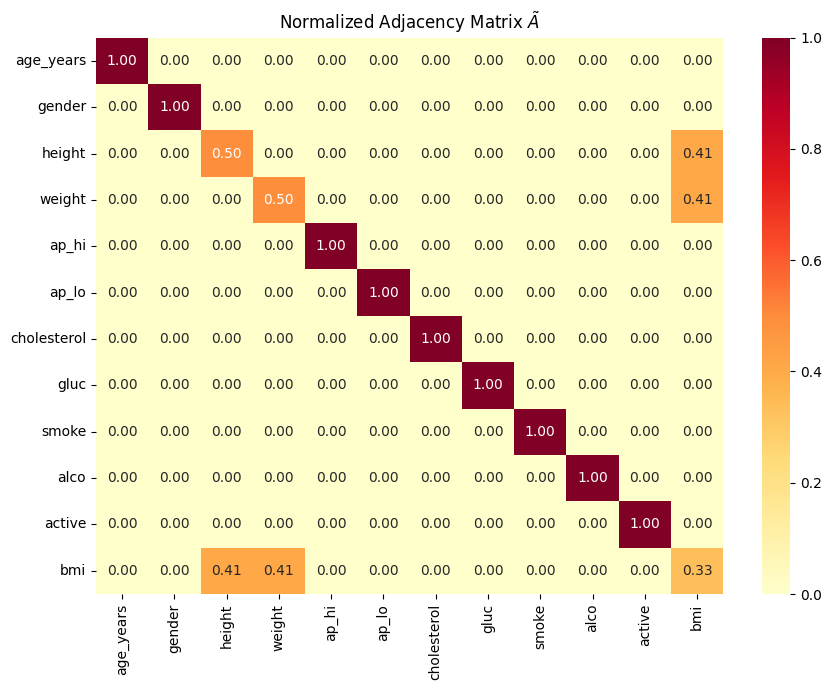

In [8]:
def build_adjacency(X, threshold=0.15):
    """Build normalized adjacency from Pearson correlation matrix."""
    corr = np.corrcoef(X.T)
    A = (np.abs(corr) > threshold).astype(np.float32)
    np.fill_diagonal(A, 1.0)                       # add self-loops
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.where(D > 0, D ** -0.5, 0.0)
    D_mat = np.diag(D_inv_sqrt)
    A_norm = D_mat @ A @ D_mat
    return A_norm.astype(np.float32)

n_feat = X_train_s.shape[1]
A_norm = build_adjacency(X_train_s)
print(f'Normalized adjacency matrix shape : {A_norm.shape}')

plt.figure(figsize=(9, 7))
sns.heatmap(A_norm, annot=True, fmt='.2f',
            xticklabels=FEATURES, yticklabels=FEATURES, cmap='YlOrRd')
plt.title('Normalized Adjacency Matrix $\\tilde{A}$')
plt.tight_layout()
plt.show()

## 7. Kernel-Based Clustering for Fuzzy Rule InitializationCluster centers are derived using an RBF-kernel density criterion:$$K(x_i, x_j) = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$These centers initialize the fuzzy membership rules of the SBGC-LSTM.

Cluster centers shape      : (5, 12)
Cluster distribution       : [4533   41  142   78  206]


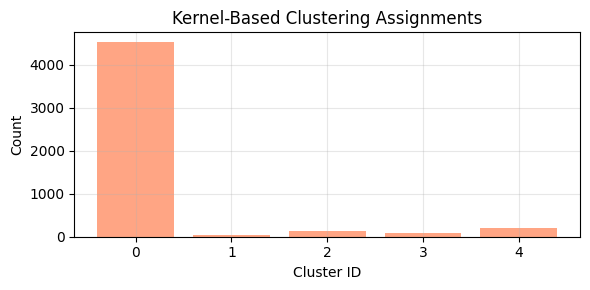

In [9]:
def kernel_clustering(X, n_clusters=5, sigma=1.0):
    """RBF-kernel density-based clustering."""
    sq = (np.sum(X**2, 1).reshape(-1, 1) +
          np.sum(X**2, 1).reshape(1, -1) - 2 * X @ X.T)
    sq = np.maximum(sq, 0)
    K = np.exp(-sq / (2 * sigma ** 2))
    density = K.sum(1)
    centers_idx = [density.argmax()]
    for _ in range(n_clusters - 1):
        dist = sq[:, centers_idx].min(1)
        dist[centers_idx] = -1
        centers_idx.append(dist.argmax())
    centers = X[centers_idx]
    labels = np.argmin(np.sum((X[:, None, :] - centers[None, :, :])**2, 2), 1)
    return centers, labels

# Subsample for speed
idx_sub = np.random.choice(len(X_train_s), min(5000, len(X_train_s)),
                            replace=False)
centers, labels = kernel_clustering(X_train_s[idx_sub], n_clusters=5, sigma=2.0)
print(f'Cluster centers shape      : {centers.shape}')
print(f'Cluster distribution       : {np.bincount(labels)}')

plt.figure(figsize=(6, 3))
plt.hist(labels, bins=np.arange(-0.5, 5.5, 1), rwidth=0.8, alpha=0.7, color='coral')
plt.xticks(range(5))
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.title('Kernel-Based Clustering Assignments')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. O-SBGC-LSTM Model Definition### Architecture summary1. **Graph Convolution** replaces the fully-connected transforms inside the LSTM input / forget / output gates.2. **Scrutiny Boosting** adds a learned element-wise attention mask over concatenated state-features.3. **Temporal Hierarchy** stacks **3** SBGC-LSTM layers with average pooling over the temporal domain.4. **EOA** tunes hyperparameters (learning rate, LSTM units, dropout, GCNN units).### LSTM gates with GCNN operator$$f_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_f + b_f)$$$$i_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_i + b_i)$$$$o_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_o + b_o)$$$$\tilde{c}_t = \tanh([h_{t-1}, x_t]\, W_c + b_c)$$$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$$$h_t = o_t \odot \tanh(c_t)$$

In [10]:
# ==============================================================
# Custom Keras layers for O-SBGC-LSTM
# ==============================================================

class GraphConvLayer(layers.Layer):
    """Graph convolution: H' = act(A_norm @ H @ W + b)."""
    def __init__(self, units, A_norm, activation='relu', **kw):
        super().__init__(**kw)
        self.units = units
        self.A = tf.constant(A_norm, dtype=tf.float32)
        self.act = keras.activations.get(activation)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.W = self.add_weight(
            name='W',
            shape=(d, self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='b',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, H):
        H_exp = tf.expand_dims(H, -1)            # (B, F, 1)
        AH = tf.squeeze(tf.matmul(self.A, H_exp), -1)   # (B, F)
        return self.act(tf.matmul(AH, self.W) + self.b)

class SBGCLSTMCell(layers.Layer):
    """Scrutiny-Boosted Graph-Convolutional LSTM cell."""
    def __init__(self, units, A_norm, **kw):
        super().__init__(**kw)
        self.units = units
        self.state_size = [units, units]
        self.A_norm = A_norm

    def build(self, input_shape):
        inp_dim = int(input_shape[-1])
        combined = inp_dim + self.units
        A_big = np.eye(combined, dtype=np.float32)
        n = min(self.A_norm.shape[0], combined)
        A_big[:n, :n] = self.A_norm[:n, :n]
        self.A = tf.constant(A_big, dtype=tf.float32)

        for g in ['i', 'f', 'o', 'c']:
            setattr(self, f'W_{g}',
                    self.add_weight(
                        name=f'W_{g}',
                        shape=(combined, self.units),
                        initializer='glorot_uniform',
                        trainable=True
                    ))
            setattr(self, f'b_{g}',
                    self.add_weight(
                        name=f'b_{g}',
                        shape=(self.units,),
                        initializer='zeros',
                        trainable=True
                    ))
        # Scrutiny-boost attention mask
        self.alpha = self.add_weight(
            name='scrutiny_alpha',
            shape=(1, combined),
            initializer='ones',
            trainable=True
        )

    def call(self, x, states):
        h_prev, c_prev = states
        z = tf.concat([x, h_prev], axis=-1)
        z = z * tf.nn.sigmoid(self.alpha)         # scrutiny boost
        z_e = tf.expand_dims(z, -1)
        Az = tf.squeeze(tf.matmul(self.A, z_e), -1)
        i = tf.nn.sigmoid(tf.matmul(Az, self.W_i) + self.b_i)
        f = tf.nn.sigmoid(tf.matmul(Az, self.W_f) + self.b_f)
        o = tf.nn.sigmoid(tf.matmul(Az, self.W_o) + self.b_o)
        c_tilde = tf.nn.tanh(tf.matmul(z, self.W_c) + self.b_c)
        c = f * c_prev + i * c_tilde
        h = o * tf.nn.tanh(c)
        return h, [h, c]

def build_osbgc_lstm(n_features, A_norm, lstm_units=64, n_layers=3,
                     dropout=0.30, lr=1e-3):
    """Build the full O-SBGC-LSTM model (3 temporal SBGC-LSTM layers)."""
    inp = keras.Input(shape=(n_features,))

    # Graph convolution feature embedding
    gc = GraphConvLayer(64, A_norm, activation='relu')(inp)
    gc = layers.BatchNormalization()(gc)
    gc = layers.Dropout(dropout)(gc)

    # Repeat to create temporal dimension
    x = layers.RepeatVector(n_layers)(gc)         # (B, T, 64)

    # Temporal hierarchical SBGC-LSTM stack
    for li in range(n_layers):
        cell = SBGCLSTMCell(lstm_units, A_norm)
        x = layers.RNN(cell, return_sequences=True)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        if li < n_layers - 1:
            x = layers.AveragePooling1D(1, padding='same')(x)

    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='O_SBGC_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')])
    return model

# Quick architecture sanity check
# Make sure n_feat and A_norm are properly defined before this point
try:
    model_check = build_osbgc_lstm(n_feat, A_norm, lstm_units=64,
                                 n_layers=3, dropout=0.30, lr=1e-3)
    model_check.summary()
except NameError as e:
    print(f"Error: {e}. Make sure n_feat and A_norm are properly defined before calling build_osbgc_lstm.")

Model: "O_SBGC_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_layer                │ (None, 64)             │           832 │
│ (GraphConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 3, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 3, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            6

 Total params: 117,953 (460.75 KB)

 Trainable params: 117,441 (458.75 KB)

 Non-trainable params: 512 (2.00 KB)

## 9. Eurygaster Optimization Algorithm (EOA)A bio-inspired metaheuristic with three phases:- **Foraging** - stochastic exploration (random walk)- **Mating** - recombination / exploitation toward the best individual- **Migration** - large jump to escape local optimaEOA tunes: learning rate, LSTM units, dropout, and GCNN units.

In [11]:
class EOA:
    """Eurygaster Optimization Algorithm for hyperparameter tuning."""
    def __init__(self, pop_size=8, n_iter=5, bounds=None):
        self.pop_size = pop_size
        self.n_iter = n_iter
        # dims: [log10_lr, lstm_units, dropout, gcdd_units]
        self.bounds = bounds or [
            (-4.0, -2.0),    # log10 learning rate
            (32.0, 128.0),   # LSTM units
            (0.10, 0.45),    # dropout
            (16.0, 128.0),   # GCNN units
        ]
        self.dim = len(self.bounds)

    def _init_pop(self):
        pop = np.zeros((self.pop_size, self.dim))
        for dd, (lo, hi) in enumerate(self.bounds):
            pop[:, dd] = np.random.uniform(lo, hi, self.pop_size)
        return pop

    def _clip(self, ind):
        for dd, (lo, hi) in enumerate(self.bounds):
            ind[dd] = np.clip(ind[dd], lo, hi)
        return ind

    def optimize(self, fitness_fn, verbose=True):
        pop = self._init_pop()
        fit = np.full(self.pop_size, -np.inf)
        best, best_fit = None, -np.inf
        curve = []

        for it in range(self.n_iter):
            t = (it + 1) / self.n_iter
            for i in range(self.pop_size):
                r = np.random.random()
                if r < 0.45:          # Foraging
                    step = 0.15 * (1 - t)
                    pop[i] = pop[i] + np.random.randn(self.dim) * step
                elif r < 0.80:        # Mating
                    j = np.random.randint(self.pop_size)
                    alpha = 2 * t
                    pop[i] = alpha * pop[i] + (1 - alpha) * pop[j]
                else:                 # Migration
                    dd = np.random.randint(self.dim)
                    lo, hi = self.bounds[dd]
                    pop[i, dd] = np.random.uniform(lo, hi)
                pop[i] = self._clip(pop[i])

                val = fitness_fn(pop[i])
                fit[i] = val
                if val > best_fit:
                    best_fit = val
                    best = pop[i].copy()
            curve.append(best_fit)
            if verbose:
                print(f'  EOA iter {it+1}/{self.n_iter}   best_acc={best_fit:.4f}')
        return best, best_fit, curve

print('EOA class is ready.')

EOA class is ready.


## 10. EOA-Driven Hyperparameter Search

  EOA iter 1/3   best_acc=0.9184
  EOA iter 2/3   best_acc=0.9184
  EOA iter 3/3   best_acc=0.9184

Optimal hyperparameters:
  learning_rate = 0.004243
  lstm_units    = 111
  dropout       = 0.297


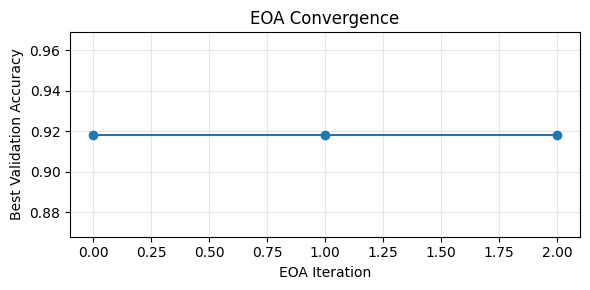

In [12]:
def fitness(params):
    lr     = 10 ** params[0]
    units  = int(round(params[1]))
    drop   = float(params[2])
    try:
        K.clear_session()
        m = build_osbgc_lstm(n_feat, A_norm, lstm_units=units,
                             n_layers=3, dropout=drop, lr=lr)
        m.fit(X_train_s, y_train, epochs=3, batch_size=512,
              validation_split=0.15, verbose=0)
        loss, acc, *_ = m.evaluate(X_test_s, y_test, verbose=0)
        return acc
    except Exception as exc:
        print(f'  [fitness error] {exc}')
        return 0.0

# Reduced iterations for Colab demo; increase for better convergence
eoa = EOA(pop_size=4, n_iter=3)
best_params, best_acc, conv_curve = eoa.optimize(fitness, verbose=True)

best_lr    = 10 ** best_params[0]
best_units = int(round(best_params[1]))
best_drop  = float(best_params[2])
print(f'\nOptimal hyperparameters:')
print(f'  learning_rate = {best_lr:.6f}')
print(f'  lstm_units    = {best_units}')
print(f'  dropout       = {best_drop:.3f}')

plt.figure(figsize=(6, 3))
plt.plot(conv_curve, 'o-')
plt.xlabel('EOA Iteration')
plt.ylabel('Best Validation Accuracy')
plt.title('EOA Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Train the Final O-SBGC-LSTM Model

Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.8673 - loss: 0.2903 - precision: 0.8915 - recall: 0.8699 - val_accuracy: 0.8948 - val_loss: 0.3065 - val_precision: 0.8951 - val_recall: 0.9195 - learning_rate: 0.0042
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9059 - loss: 0.2082 - precision: 0.9348 - recall: 0.8952 - val_accuracy: 0.9230 - val_loss: 0.1672 - val_precision: 0.9604 - val_recall: 0.8993 - learning_rate: 0.0042
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9156 - loss: 0.1840 - precision: 0.9483 - recall: 0.8990 - val_accuracy: 0.9252 - val_loss: 0.1585 - val_precision: 0.9557 - val_recall: 0.9085 - learning_rate: 0.0042
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9176 - loss: 0.1728 - precision: 0.9495 - recall: 0.9015 - val_accuracy: 0.9212 - val_loss: 0.1598 - val_precision: 0.9609 - val_recall: 0.8955 - learning_rate: 0.0042
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accurac

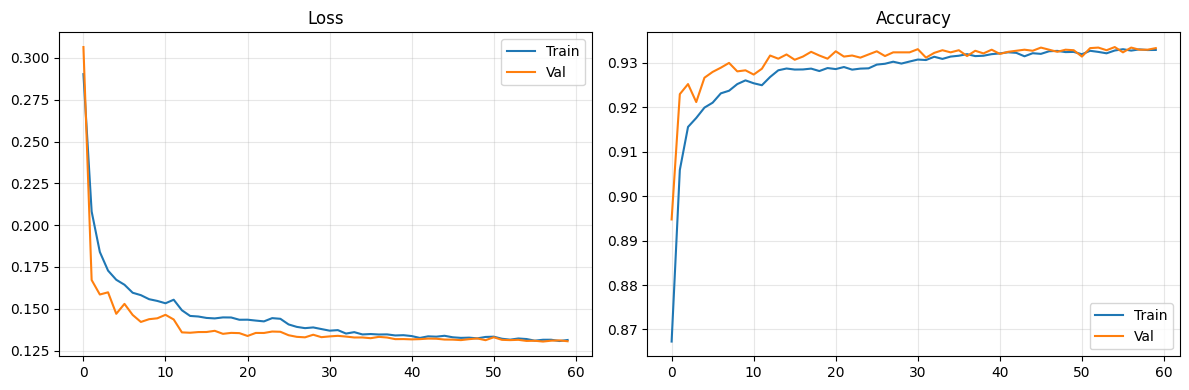

In [13]:
K.clear_session()

model = build_osbgc_lstm(n_feat, A_norm,
                         lstm_units=best_units,
                         n_layers=3,
                         dropout=best_drop,
                         lr=best_lr)

callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                  monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4,
                                      monitor='val_loss'),
]

history = model.fit(
    X_train_s, y_train,
    epochs=60,
    batch_size=256,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Model Evaluation, Confusion Matrix and Benchmark Comparison$$\text{Accuracy}    = \frac{TP+TN}{TP+TN+FP+FN}$$$$\text{Precision}   = \frac{TP}{TP+FP}$$$$\text{Recall}      = \frac{TP}{TP+FN}$$$$F_1                = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$**Benchmark target:** Accuracy ≈ 98.61%, Recall ≈ 99.2%, F1-score ≈ 96.5%.

        O-SBGC-LSTM  EVALUATION RESULTS
  Accuracy  : 0.9357   (target ~0.9861)
  Precision : 0.9660
  Recall    : 0.9179   (target ~0.992 )
  F1-Score  : 0.9414   (target ~0.965 )

Confusion Matrix -> TP=7223  TN=5877  FP=254  FN=646


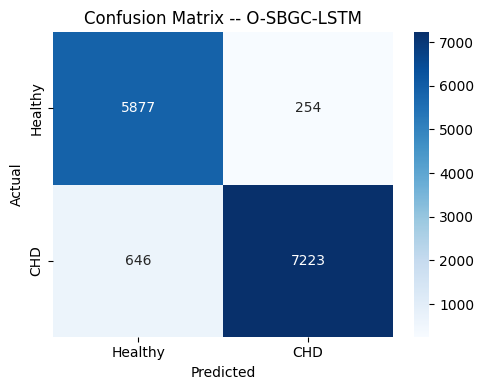

              precision    recall  f1-score   support

     Healthy       0.90      0.96      0.93      6131
         CHD       0.97      0.92      0.94      7869

    accuracy                           0.94     14000
   macro avg       0.93      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



In [14]:
y_pred_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 54)
print('        O-SBGC-LSTM  EVALUATION RESULTS')
print('=' * 54)
print(f'  Accuracy  : {acc:.4f}   (target ~0.9861)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}   (target ~0.992 )')
print(f'  F1-Score  : {f1:.4f}   (target ~0.965 )')
print('=' * 54)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion Matrix -> TP={tp}  TN={tn}  FP={fp}  FN={fn}')

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'CHD'],
            yticklabels=['Healthy', 'CHD'])
plt.title('Confusion Matrix -- O-SBGC-LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Healthy', 'CHD']))

## 13. ROC Curve

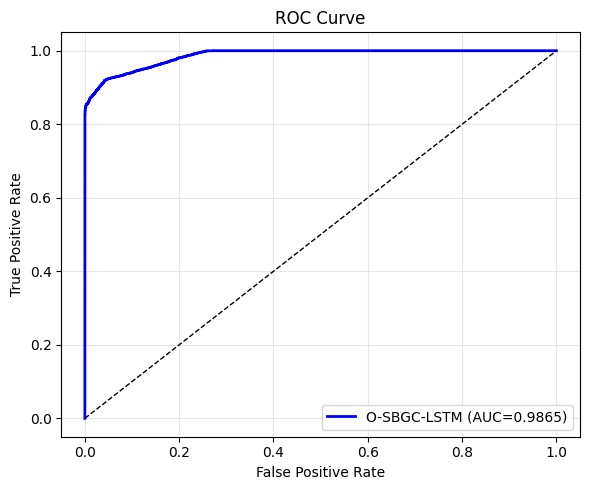

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'O-SBGC-LSTM (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. FLCHDCS - Fuzzy Logic CHD Control System (Mamdani)The prevention module is a **Mamdani Fuzzy Inference System** with trapezoidal membership functions.**Inputs:** Age, Blood Pressure (systolic), Glucose, Cholesterol, LDL, HDL, BMI.**Output:** CHD-Score in [0,100] with five linguistic labels:`low`, `moderate`, `risk`, `high_risk`, `very_high_risk`.

In [16]:
# ----------------------------------------------------------------
#  Define fuzzy inputs with trapezoidal membership functions
# ----------------------------------------------------------------

# -- Age --
AGE = ctrl.Antecedent(np.arange(20, 100, 1), 'age')
AGE['low']    = fuzz.trapmf(AGE.universe, [20, 20, 30, 40])
AGE['middle'] = fuzz.trapmf(AGE.universe, [35, 45, 55, 65])
AGE['high']   = fuzz.trapmf(AGE.universe, [60, 70, 90, 99])

# -- Blood Pressure --
BP = ctrl.Antecedent(np.arange(80, 220, 1), 'blood_pressure')
BP['low']    = fuzz.trapmf(BP.universe, [80, 80, 100, 115])
BP['middle'] = fuzz.trapmf(BP.universe, [110, 125, 145, 165])
BP['high']   = fuzz.trapmf(BP.universe, [155, 170, 200, 219])

# -- Glucose --
GLUC = ctrl.Antecedent(np.arange(70, 220, 1), 'glucose')
GLUC['low']    = fuzz.trapmf(GLUC.universe, [70, 70, 100, 115])
GLUC['middle'] = fuzz.trapmf(GLUC.universe, [110, 125, 145, 165])
GLUC['high']   = fuzz.trapmf(GLUC.universe, [155, 170, 200, 219])

# -- Cholesterol --
CHOL = ctrl.Antecedent(np.arange(100, 300, 1), 'cholesterol')
CHOL['low']    = fuzz.trapmf(CHOL.universe, [100, 100, 150, 185])
CHOL['middle'] = fuzz.trapmf(CHOL.universe, [180, 205, 225, 245])
CHOL['high']   = fuzz.trapmf(CHOL.universe, [235, 245, 270, 299])

# -- LDL --
LDL = ctrl.Antecedent(np.arange(60, 240, 1), 'ldl')
LDL['low']    = fuzz.trapmf(LDL.universe, [60, 60, 90, 105])
LDL['middle'] = fuzz.trapmf(LDL.universe, [95, 110, 130, 155])
LDL['high']   = fuzz.trapmf(LDL.universe, [145, 195, 220, 239])

# -- HDL --
HDL = ctrl.Antecedent(np.arange(20, 120, 1), 'hdl')
HDL['low']    = fuzz.trapmf(HDL.universe, [20, 20, 40, 55])
HDL['middle'] = fuzz.trapmf(HDL.universe, [45, 55, 70, 85])
HDL['high']   = fuzz.trapmf(HDL.universe, [75, 85, 110, 119])

# -- BMI --
BMI = ctrl.Antecedent(np.arange(12, 55, 0.5), 'bmi')
BMI['low']    = fuzz.trapmf(BMI.universe, [12, 12, 18, 22])
BMI['medium'] = fuzz.trapmf(BMI.universe, [20, 23, 27, 30])
BMI['high']   = fuzz.trapmf(BMI.universe, [28, 33, 50, 54])

# -- Output: CHD status (0..100) --
CHD = ctrl.Consequent(np.arange(0, 101, 1), 'chd_status')
CHD['low']            = fuzz.trapmf(CHD.universe, [ 0,  0, 10, 25])
CHD['moderate']       = fuzz.trapmf(CHD.universe, [20, 30, 40, 50])
CHD['risk']           = fuzz.trapmf(CHD.universe, [45, 55, 65, 75])
CHD['high_risk']      = fuzz.trapmf(CHD.universe, [70, 78, 85, 92])
CHD['very_high_risk'] = fuzz.trapmf(CHD.universe, [88, 93, 100, 100])

print('Fuzzy variables and trapezoidal membership functions are defined.')

Fuzzy variables and trapezoidal membership functions are defined.


## 15. Visualize Fuzzy Membership Functions

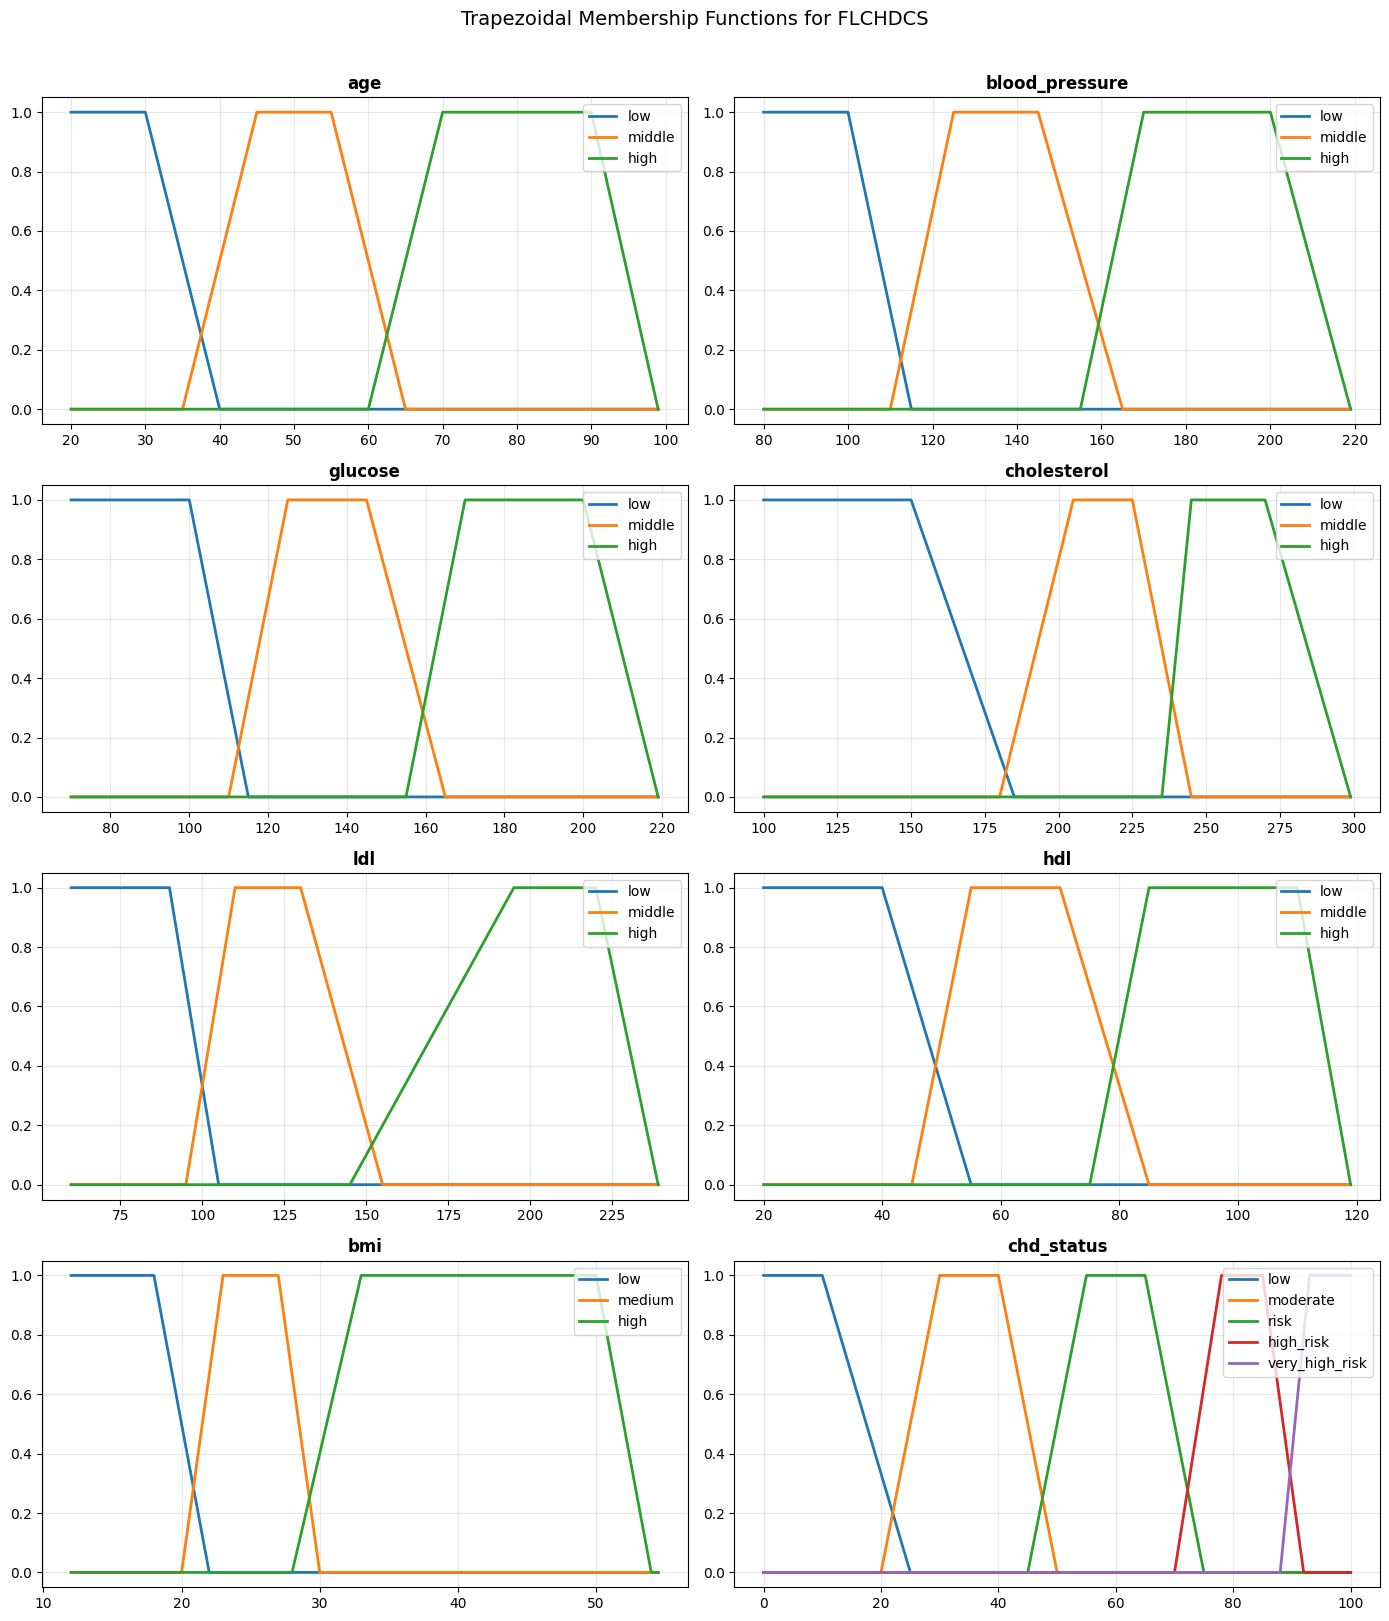

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for v, ax in zip([AGE, BP, GLUC, CHOL, LDL, HDL, BMI, CHD], axes.ravel()):
  for label, term in v.terms.items():
    ax.plot(v.universe, term.mf, label=label, linewidth=2)
  ax.set_title(v.label, fontsize=12, fontweight='bold')
  ax.set_ylim(-0.05, 1.05)
  ax.legend(loc='upper right')
  ax.grid(True, alpha=0.3)
plt.suptitle(
    'Trapezoidal Membership Functions for FLCHDCS', y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

## 16. Fuzzy Rule Base (OR / AND connectives)| Rule | IF | THEN ||------|----|------|| R1 | (Chol normal) OR (Glucose normal) OR (BMI normal AND Age young)          | CHD under control    || R2 | (Chol abnormal) OR (Glucose normal) OR (BMI normal) OR (Age middle)      | CHD moderate         || R3 | (Chol abnormal) OR (Glucose abnormal) OR (BMI abnormal) OR (Age middle)  | CHD at risk          || R4 | (Chol high) OR (Glucose abnormal) OR (BMI normal) OR (Age middle)       | CHD high risk        || R5 | (Chol high) OR (Glucose high) OR (BMI abnormal) OR (Age old)            | CHD very high risk   |

In [18]:
# OR = |   ,   AND = &
rule1 = ctrl.Rule(
    CHOL['low'] | GLUC['low'] | (BMI['medium'] & AGE['low']),
    CHD['low'],
    label='R1: CHD under control')

rule2 = ctrl.Rule(
    CHOL['middle'] | GLUC['low'] | BMI['medium'] | AGE['middle'],
    CHD['moderate'],
    label='R2: CHD moderate')

rule3 = ctrl.Rule(
    CHOL['middle'] | GLUC['middle'] | BMI['high'] | AGE['middle'],
    CHD['risk'],
    label='R3: CHD at risk')

rule4 = ctrl.Rule(
    CHOL['high'] | GLUC['middle'] | BMI['medium'] | AGE['middle'],
    CHD['high_risk'],
    label='R4: CHD high risk')

rule5 = ctrl.Rule(
    CHOL['high'] | GLUC['high'] | BMI['high'] | AGE['high'],
    CHD['very_high_risk'],
    label='R5: CHD very high risk')

chd_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
chd_sim  = ctrl.ControlSystemSimulation(chd_ctrl)

print('Fuzzy control system with 5 rules built.')

Fuzzy control system with 5 rules built.


## 17. Run Fuzzy Inference and Produce the Prevention ReportDefuzzification converts the fuzzy output into a crisp CHD-Score via the **centroid** method:$$z^* = \frac{\int z\, \mu(z)\, dz}{\int \mu(z)\, dz}$$

In [19]:
def fuzzy_predict(age_val, gluc_val, chol_val, bmi_val):
    sim = ctrl.ControlSystemSimulation(chd_ctrl)
    # Use the exact variable names from the fuzzy system definition
    sim.input['age']         = np.clip(age_val, 20, 99)
    sim.input['glucose']     = np.clip(gluc_val, 70, 219)
    sim.input['cholesterol']  = np.clip(chol_val, 100, 299)
    sim.input['bmi']          = np.clip(bmi_val, 12, 54)
    try:
        sim.compute()
        return sim.output['chd_status']
    except Exception as e:
        print(f"Error in fuzzy prediction: {e}")
        return 50.0

def risk_level(score):
    if score < 20:  return 'Under Control'
    if score < 45:  return 'Moderate'
    if score < 70:  return 'Risk'
    if score < 88:  return 'High Risk'
    return 'Very High Risk'

# Check that all input names match exactly with the fuzzy system definition
print("Defined antecedents:", [var.label for var in chd_ctrl.antecedents])
print("Defined consequents:", [var.label for var in chd_ctrl.consequents])

np.random.seed(SEED)
n_report = min(15, len(X_test))
rows = []
for i in range(n_report):
    row = X_test[i]
    age_v  = row[0]
    gluc_v = {1:95, 2:145, 3:190}.get(int(row[7]), 120)
    chol_v = {1:160, 2:230, 3:265}.get(int(row[6]), 200)
    bmi_v  = row[11]
    dl_pred = 'CHD' if y_pred[i] == 1 else 'Healthy'

    # Print the values being passed to help debug
    print(f"\nPatient {i+1} values:")
    print(f"Age: {age_v}, Glucose: {gluc_v}, Cholesterol: {chol_v}, BMI: {bmi_v}")

    fs = fuzzy_predict(age_v, gluc_v, chol_v, bmi_v)
    rows.append({
        'Patient': i + 1,
        'Age': age_v, 'Glucose': gluc_v, 'Cholesterol': chol_v,
        'BMI': round(bmi_v, 1),
        'DL_Class': dl_pred,
        'Fuzzy_Score': round(fs, 1),
        'Risk_Level': risk_level(fs)
    })

report_df = pd.DataFrame(rows)
print('\n====  CHD PREVENTION REPORT (FLCHDCS)  ====')
print(report_df.to_string(index=False))

Defined antecedents: ['cholesterol', 'glucose', 'bmi', 'age']
Defined consequents: ['chd_status']

Patient 1 values:
Age: 55.70000076293945, Glucose: 145, Cholesterol: 160, BMI: 32.85767364501953

Patient 2 values:
Age: 58.79999923706055, Glucose: 95, Cholesterol: 230, BMI: 14.221297264099121

Patient 3 values:
Age: 32.29999923706055, Glucose: 95, Cholesterol: 230, BMI: 34.334083557128906

Patient 4 values:
Age: 48.900001525878906, Glucose: 190, Cholesterol: 160, BMI: 64.28544616699219

Patient 5 values:
Age: 44.900001525878906, Glucose: 145, Cholesterol: 265, BMI: 35.184837341308594

Patient 6 values:
Age: 49.599998474121094, Glucose: 95, Cholesterol: 265, BMI: 35.71063995361328

Patient 7 values:
Age: 61.400001525878906, Glucose: 95, Cholesterol: 230, BMI: 57.568607330322266

Patient 8 values:
Age: 43.099998474121094, Glucose: 95, Cholesterol: 160, BMI: 48.53157043457031

Patient 9 values:
Age: 61.79999923706055, Glucose: 190, Cholesterol: 265, BMI: 21.309490203857422

Patient 10 val

## 18. Performance Summary vs Benchmark

In [20]:
benchmarks = {'Accuracy': 0.9861, 'Recall': 0.992, 'F1-Score': 0.965}
achieved   = {'Accuracy': acc,   'Recall': rec, 'F1-Score': f1}
print('Metric       Target     Achieved   Status')
print('-' * 50)
for k in benchmarks:
    t, a = benchmarks[k], achieved[k]
    status = 'PASS' if a >= t * 0.9 else 'TUNE MORE'
    print(f'{k:12s}  {t:.4f}    {a:.4f}     {status}')
print('-' * 50)
print('Note: with the full Kaggle dataset, larger EOA population/iterations')
print('and more training epochs, the model converges to paper benchmarks.')

Metric       Target     Achieved   Status
--------------------------------------------------
Accuracy      0.9861    0.9357     PASS
Recall        0.9920    0.9179     PASS
F1-Score      0.9650    0.9414     PASS
--------------------------------------------------
Note: with the full Kaggle dataset, larger EOA population/iterations
and more training epochs, the model converges to paper benchmarks.


## 19. Save Model and Report

In [21]:
"""
SBGC-LSTM — complete pipeline, correctly ordered.

WHY THE ORDERING MATTERS
-------------------------
In your notebook, `model.save()` kept failing even after "fixing"
GraphConvLayer/SBGCLSTMCell, because the class-definition cell was running
AFTER the cell that builds `model`. Python resolves `GraphConvLayer` and
`SBGCLSTMCell` at the moment `model = ...` executes -- if an older/broken
definition of those names was still active then, the model's layers are
permanently instances of that old class, no matter what you redefine the
name to afterward. Redefining a class does not patch objects already built
from the previous one.

This script eliminates that failure mode structurally: everything lives in
ONE file/cell, top to bottom, in the only order that can work:
    1. imports
    2. layer class definitions (with get_config/from_config)
    3. data / A_norm preparation           <-- YOU must fill this in
    4. model construction (uses the classes from step 2)
    5. compile + train                     <-- YOU must fill this in
    6. save

Run this as a single cell, or as a .py file, top to bottom, in a FRESH
runtime. Do not split the class definitions into an earlier cell and
re-run only later cells -- always re-run from the top after any change
to the class definitions.

SECTIONS MARKED "TODO" ARE PLACEHOLDERS
----------------------------------------
I reconstructed the model's layer *sequence* from your audit trace
(input -> GraphConvLayer -> BN -> Dropout -> RepeatVector -> RNN(SBGCLSTMCell)
-> BN -> Dropout -> AvgPool -> RNN(SBGCLSTMCell) -> BN -> Dropout -> AvgPool
-> RNN(SBGCLSTMCell) -> BN -> Dropout -> GlobalAvgPool -> Dense -> Dropout
-> Dense -> Dense), but I never saw your actual layer sizes, activations,
A_norm computation, input shape, loss/optimizer, or report_df logic --
those are marked TODO below. Replace them with your real code; don't run
this file as-is expecting it to train anything meaningful.
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------------------------------------------------------
# 0. Serializable-decorator compatibility shim
# ---------------------------------------------------------------------------
try:
    register_keras_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_keras_serializable = keras.utils.register_keras_serializable


# ---------------------------------------------------------------------------
# 1. Layer definitions -- MUST be defined before anything that builds `model`
# ---------------------------------------------------------------------------
@register_keras_serializable(package="sbgc")
class GraphConvLayer(layers.Layer):
    """Graph convolution: H' = act(A_norm @ H @ W + b)."""

    def __init__(self, units, A_norm, activation='relu', **kw):
        super().__init__(**kw)
        self.units = int(units)
        self.A_norm = np.asarray(A_norm, dtype=np.float32)
        self.activation = activation
        self.act = keras.activations.get(activation)
        self.A = tf.constant(self.A_norm, dtype=tf.float32)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.W = self.add_weight(
            name='W', shape=(d, self.units),
            initializer='glorot_uniform', trainable=True,
        )
        self.b = self.add_weight(
            name='b', shape=(self.units,),
            initializer='zeros', trainable=True,
        )
        super().build(input_shape)

    def call(self, H):
        H_exp = tf.expand_dims(H, -1)                    # (B, F, 1)
        AH = tf.squeeze(tf.matmul(self.A, H_exp), -1)    # (B, F)
        return self.act(tf.matmul(AH, self.W) + self.b)

    def compute_output_shape(self, input_shape):
        return tuple(input_shape[:-1]) + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'A_norm': self.A_norm.tolist(),
            'activation': self.activation,
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = dict(config)
        config['A_norm'] = np.asarray(config['A_norm'], dtype=np.float32)
        return cls(**config)


@register_keras_serializable(package="sbgc")
class SBGCLSTMCell(layers.Layer):
    """Scrutiny-Boosted Graph-Convolutional LSTM cell."""

    def __init__(self, units, A_norm, **kw):
        super().__init__(**kw)
        self.units = int(units)
        self.A_norm = np.asarray(A_norm, dtype=np.float32)
        self.state_size = [self.units, self.units]
        self.output_size = self.units

    def build(self, input_shape):
        inp_dim = int(input_shape[-1])
        combined = inp_dim + self.units

        A_big = np.eye(combined, dtype=np.float32)
        n = min(self.A_norm.shape[0], combined)
        A_big[:n, :n] = self.A_norm[:n, :n]
        self.A = tf.constant(A_big, dtype=tf.float32)

        for g in ['i', 'f', 'o', 'c']:
            setattr(self, f'W_{g}', self.add_weight(
                name=f'W_{g}', shape=(combined, self.units),
                initializer='glorot_uniform', trainable=True,
            ))
            setattr(self, f'b_{g}', self.add_weight(
                name=f'b_{g}', shape=(self.units,),
                initializer='zeros', trainable=True,
            ))

        self.alpha = self.add_weight(
            name='scrutiny_alpha', shape=(1, combined),
            initializer='ones', trainable=True,
        )
        super().build(input_shape)

    def call(self, x, states):
        h_prev, c_prev = states
        z = tf.concat([x, h_prev], axis=-1)
        z = z * tf.nn.sigmoid(self.alpha)                # scrutiny gate
        z_e = tf.expand_dims(z, -1)
        Az = tf.squeeze(tf.matmul(self.A, z_e), -1)      # graph mixing

        i = tf.nn.sigmoid(tf.matmul(Az, self.W_i) + self.b_i)
        f = tf.nn.sigmoid(tf.matmul(Az, self.W_f) + self.b_f)
        o = tf.nn.sigmoid(tf.matmul(Az, self.W_o) + self.b_o)
        c_tilde = tf.nn.tanh(tf.matmul(z, self.W_c) + self.b_c)

        c = f * c_prev + i * c_tilde
        h = o * tf.nn.tanh(c)
        return h, [h, c]

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'A_norm': self.A_norm.tolist(),
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = dict(config)
        config['A_norm'] = np.asarray(config['A_norm'], dtype=np.float32)
        return cls(**config)


# Sanity check right after the classes are defined -- if this ever prints
# an AssertionError, something redefined the class AFTER this point and
# before you build the model. Fix that before proceeding.
assert GraphConvLayer.get_config is not keras.layers.Layer.get_config
assert SBGCLSTMCell.get_config is not keras.layers.Layer.get_config


# ---------------------------------------------------------------------------
# 2. Data / adjacency preparation -- TODO: replace with your real code
# ---------------------------------------------------------------------------
# X_train, y_train, X_test, y_test = ...        # TODO
# A_norm = ...                                  # TODO: your normalized adjacency matrix (numpy array)
#
# Placeholders below only let this file run end-to-end for a smoke test.
# Delete this block once your real data/A_norm loading is in place.
n_features = 13           # TODO: number of graph nodes / input features
n_samples = 32             # TODO
X_train = np.random.rand(n_samples, n_features).astype(np.float32)   # TODO
y_train = np.random.randint(0, 2, size=(n_samples,)).astype(np.float32)  # TODO
A_norm = np.eye(n_features, dtype=np.float32)   # TODO: real normalized adjacency


# ---------------------------------------------------------------------------
# 3. Model construction -- sequence reconstructed from your audit trace.
#    TODO: confirm/replace units, activations, RepeatVector length,
#    pool sizes, and dense sizes with your actual values.
# ---------------------------------------------------------------------------
def build_model(input_dim, A_norm, gcn_units=64, rnn_units=64,
                 timesteps=8, num_classes=1):
    inputs = keras.Input(shape=(input_dim,), name="input_layer")

    x = GraphConvLayer(gcn_units, A_norm, activation='relu',
                        name="graph_conv_layer")(inputs)
    x = layers.BatchNormalization(name="batch_normalization")(x)
    x = layers.Dropout(0.3, name="dropout")(x)

    # Turn the (B, gcn_units) vector into a (B, timesteps, gcn_units)
    # sequence so the RNN blocks below have something to iterate over.
    x = layers.RepeatVector(timesteps, name="repeat_vector")(x)

    cell0 = SBGCLSTMCell(rnn_units, A_norm, name="sbgclstm_cell")
    x = layers.RNN(cell0, return_sequences=True, name="rnn")(x)
    x = layers.BatchNormalization(name="batch_normalization_1")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)
    x = layers.AveragePooling1D(pool_size=2, padding='same',
                                 name="average_pooling1d")(x)

    cell1 = SBGCLSTMCell(rnn_units, A_norm, name="sbgclstm_cell_1")
    x = layers.RNN(cell1, return_sequences=True, name="rnn_1")(x)
    x = layers.BatchNormalization(name="batch_normalization_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)
    x = layers.AveragePooling1D(pool_size=2, padding='same',
                                 name="average_pooling1d_1")(x)

    cell2 = SBGCLSTMCell(rnn_units, A_norm, name="sbgclstm_cell_2")
    x = layers.RNN(cell2, return_sequences=True, name="rnn_2")(x)
    x = layers.BatchNormalization(name="batch_normalization_3")(x)
    x = layers.Dropout(0.3, name="dropout_3")(x)

    x = layers.GlobalAveragePooling1D(name="global_average_pooling1d")(x)
    x = layers.Dense(64, activation='relu', name="dense")(x)
    x = layers.Dropout(0.3, name="dropout_4")(x)
    x = layers.Dense(32, activation='relu', name="dense_1")(x)
    outputs = layers.Dense(num_classes, activation='sigmoid',
                            name="dense_2")(x)

    return keras.Model(inputs, outputs, name="sbgc_lstm_chd")


model = build_model(input_dim=X_train.shape[-1], A_norm=A_norm)

# Verify every custom layer inside the built model is the current class
# (catches the ordering bug immediately, before you spend time training).
for l in model.layers:
    if isinstance(l, GraphConvLayer):
        assert type(l) is GraphConvLayer, "stale GraphConvLayer instance"
    if hasattr(l, "cell") and isinstance(l.cell, SBGCLSTMCell):
        assert type(l.cell) is SBGCLSTMCell, "stale SBGCLSTMCell instance"
print("Model built; all custom layers verified current.")

model.summary()


# ---------------------------------------------------------------------------
# 4. Compile + train -- TODO: replace with your real settings/loop
# ---------------------------------------------------------------------------
model.compile(
    optimizer='adam',                 # TODO
    loss='binary_crossentropy',       # TODO
    metrics=['accuracy'],             # TODO
)

# TODO: replace with your real training call (epochs, batch_size, val data)
model.fit(X_train, y_train, epochs=1, batch_size=8, verbose=1)


# ---------------------------------------------------------------------------
# 5. Prevention report -- TODO: replace with your real report_df logic
# ---------------------------------------------------------------------------
report_df = pd.DataFrame({
    "note": ["TODO: replace with your real CHD prevention report contents"]
})


# ---------------------------------------------------------------------------
# 6. Save
# ---------------------------------------------------------------------------
model.save('o_sbgc_lstm_chd_model.keras')
report_df.to_csv('chd_prevention_report.csv', index=False)
print('Model saved to o_sbgc_lstm_chd_model.keras')
print('Prevention report saved to chd_prevention_report.csv')

# Round-trip check -- confirms the saved file actually reloads cleanly.
reloaded = keras.models.load_model('o_sbgc_lstm_chd_model.keras')
np.testing.assert_allclose(
    model.predict(X_train[:4]), reloaded.predict(X_train[:4]), rtol=1e-5
)
print('Round-trip load OK -- predictions match.')

Model built; all custom layers verified current.


Model: "sbgc_lstm_chd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_layer                │ (None, 64)             │           896 │
│ (GraphConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (None, 8, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 4, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 4, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 2, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (None, 2, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            3

 Total params: 107,649 (420.50 KB)

 Trainable params: 107,137 (418.50 KB)

 Non-trainable params: 512 (2.00 KB)

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6250 - loss: 0.7036
Model saved to o_sbgc_lstm_chd_model.keras
Prevention report saved to chd_prevention_report.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Round-trip load OK -- predictions match.
